In [1]:
# Hybrid SSIM
!pip install pytorch-msssim
from pytorch_msssim import ssim

In [2]:
# Cell 1: Setup
import os, glob
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from tqdm import tqdm
from skimage.transform import resize
import matplotlib.pyplot as plt


# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Paths & params
DATA_DIR = r"D:\Processed"
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-4
SEQ_IN, SEQ_OUT = 4, 2
IMG_SHAPE = (400,400)


In [3]:
# Cell 2: Dataset
from skimage.transform import resize

class CloudDataset(Dataset):
    def __init__(self, data_dir, img_shape=(400, 400)):
        self.files = sorted(glob.glob(f"{data_dir}/*.npz"))
        self.img_shape = img_shape

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        data = np.load(self.files[idx])
        inp = data["input"]   # (4, H, W)
        tgt = data["target"]  # (2, H, W)
        # Resize to match IMG_SHAPE if necessary
        if inp.shape[1:] != self.img_shape:
            inp = np.stack([resize(frame, self.img_shape, preserve_range=True) for frame in inp], axis=0)
            tgt = np.stack([resize(frame, self.img_shape, preserve_range=True) for frame in tgt], axis=0)
        inp = torch.from_numpy(inp).float()  # (4, 400, 400)
        tgt = torch.from_numpy(tgt).float()  # (2, 400, 400)
        # Transpose inp to (C, H, W) with C=4
        inp = inp.permute(1, 2, 0)  # (400, 400, 4), then adjust in DataLoader to (B, 4, H, W)
        return inp, tgt

# Use num_workers=0 to debug issues in __getitem__
loader = DataLoader(CloudDataset(DATA_DIR), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

In [4]:
# Cell 3: UNet
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=4, base_c=32, out_frames=2):
        super().__init__()
        # encoder
        self.dc1 = DoubleConv(in_channels, base_c)
        self.pool = nn.MaxPool2d(2)
        self.dc2 = DoubleConv(base_c, base_c*2)
        self.dc3 = DoubleConv(base_c*2, base_c*4)
        # decoder
        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, 2, stride=2)
        self.dc4 = DoubleConv(base_c*4, base_c*2)
        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, 2, stride=2)
        self.dc5 = DoubleConv(base_c*2, base_c)
        # output: 2 frames
        self.out = nn.Conv2d(base_c, out_frames, 1)

    def forward(self, x):
        x1 = self.dc1(x)
        x2 = self.dc2(self.pool(x1))
        x3 = self.dc3(self.pool(x2))
        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.dc4(x)
        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.dc5(x)
        return self.out(x)   # shape: (B,2,H,W)

model = UNet().to(DEVICE)


In [11]:
# Cell 5: Diffusion utils
class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, x0, t, noise=None):
        if noise is None: 
            noise = torch.randn_like(x0)
        a_hat = self.alpha_hat.to(x0.device)[t].unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        return torch.sqrt(a_hat)*x0 + torch.sqrt(1 - a_hat)*noise

    def p_sample(self, model, xt, t, cond_inp):
        beta_t = self.betas[t].to(xt.device)
        alpha_t = 1 - beta_t
        alpha_hat_t = self.alpha_hat.to(xt.device)[t]
        alpha_hat_t = alpha_hat_t.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        # Use conditioning input (cond_inp) with 4 channels
        noise_pred = model(cond_inp)  # Predict using conditioning input
        mean = (1/torch.sqrt(alpha_t))*(xt - (beta_t/torch.sqrt(1-alpha_hat_t))*noise_pred)
        noise = torch.randn_like(xt) if t > 0 else 0
        return mean + torch.sqrt(beta_t)*noise

    def sample(self, model, shape, cond_inp):
        xt = torch.randn(shape).to(DEVICE)
        for t in reversed(range(self.T)):
            xt = self.p_sample(model, xt, t, cond_inp)
        return xt

diff = Diffusion()

In [5]:
# Cell 4: Diffusion utils
class Diffusion:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02):
        self.T = T
        self.betas = torch.linspace(beta_start, beta_end, T)
        self.alphas = 1 - self.betas
        self.alpha_hat = torch.cumprod(self.alphas, dim=0)

    def q_sample(self, x0, t, noise=None):
        if noise is None: noise = torch.randn_like(x0)
        a_hat = self.alpha_hat.to(x0.device)[t].unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        return torch.sqrt(a_hat)*x0 + torch.sqrt(1 - a_hat)*noise

    def p_sample(self, model, xt, t):
        beta_t = self.betas[t].to(xt.device)
        alpha_t = 1 - beta_t
        alpha_hat_t = self.alpha_hat.to(xt.device)[t]
        alpha_hat_t = alpha_hat_t.unsqueeze(-1).unsqueeze(-1)
        # predict noise
        noise_pred = model(xt)
        # for multi-output model, use only first frame's channel to denoise
        # here we denoise all channels separately
        mean = (1/torch.sqrt(alpha_t))*(xt - (beta_t/torch.sqrt(1-alpha_hat_t))*noise_pred)
        noise = torch.randn_like(xt) if t>0 else 0
        return mean + torch.sqrt(beta_t)*noise

    def sample(self, model, shape):
        xt = torch.randn(shape).to(DEVICE)
        for t in reversed(range(self.T)):
            xt = self.p_sample(model, xt, t)
        return xt

diff = Diffusion()


In [6]:
# Cell 5: Loss
mse = nn.MSELoss()
def hybrid_loss(pred, target):
    # pred, target: (B,2,H,W)
    l2 = mse(pred, target)
    s = 0
    for i in range(pred.shape[1]):
        s += 1 - ssim(pred[:,i].unsqueeze(1), target[:,i].unsqueeze(1), data_range=1.0, size_average=True)
    ssim_loss = s / pred.shape[1]
    return 0.5*l2 + 0.5*ssim_loss


In [9]:
# Cell 6: Train
opt = Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for inp, tgt in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        # inp: (B,4,H,W) → treat as channels
        x0 = tgt.to(DEVICE)            # (B,2,H,W)
        t = torch.randint(0, diff.T//2, (x0.size(0),), device=DEVICE)  # restrict noise
        # noise both frames

        xt = diff.q_sample(x0, t)  # Noise both frames
        pred = model(inp.to(DEVICE).permute(0, 3, 1, 2))  # Permute from [B, H, W, C] to [B, C, H, W]
        loss = hybrid_loss(pred, x0)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} avg loss: {total_loss/len(loader):.4f}")


Epoch 1/20: 100%|██████████| 1113/1113 [17:56<00:00,  1.03it/s]


Epoch 1 avg loss: 0.1367


Epoch 2/20: 100%|██████████| 1113/1113 [20:53<00:00,  1.13s/it]


Epoch 2 avg loss: 0.1101


Epoch 3/20: 100%|██████████| 1113/1113 [15:25<00:00,  1.20it/s]


...

Epoch 18 avg loss: 0.0864


Epoch 19/20: 100%|██████████| 1113/1113 [14:58<00:00,  1.24it/s]


Epoch 19 avg loss: 0.0861


Epoch 20/20: 100%|██████████| 1113/1113 [14:57<00:00,  1.24it/s]

Epoch 20 avg loss: 0.0857


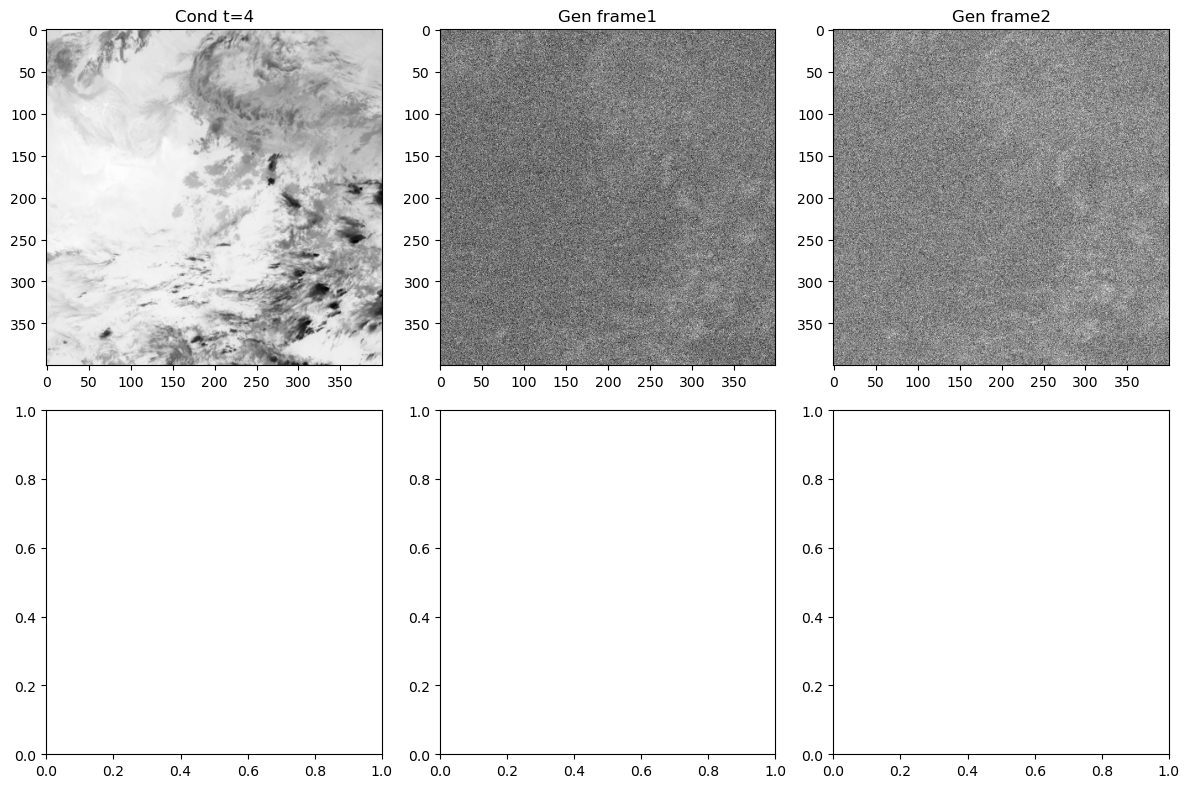

In [12]:
# Cell 7: Demo generation
model.eval()
with torch.no_grad():
    # condition input: take last batch’s inputs
    inp, _ = next(iter(loader))
    inp = inp.to(DEVICE).permute(0, 3, 1, 2)  # Ensure [B, 4, 400, 400]
    # sample new cloud frames (random noise → two-frame output)
    gen = diff.sample(model, (inp.size(0), 2, *IMG_SHAPE), cond_inp=inp)
    # visualize first sample
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes[0,0].imshow(inp[0,3].cpu(), cmap='gray'); axes[0,0].set_title("Cond t=4")
    axes[0,1].imshow(gen[0,0].cpu(), cmap='gray'); axes[0,1].set_title("Gen frame1")
    axes[0,2].imshow(gen[0,1].cpu(), cmap='gray'); axes[0,2].set_title("Gen frame2")
    plt.tight_layout()
    plt.show()